# Lecture 09, Notebook 11: OLG Exercise — Closed-Form Savings Rates and Lifecycle Profiles

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §5.5 (the 6-agent analytic Krueger–Kübler OLG); a self-contained warm-up complementing Chapter 5 Exercises 5.1–5.2  
**Notebook role:** exercise  
**Author:** Simon Scheidegger

In [ ]:
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0

# Exercise: OLG Savings Rates and Lifecycle Profiles

In this exercise, you will work with the **analytical OLG model** of Notebook 08 (the persistent-simulation primary).

**Goals (approx. 30 min):**
1. Compute closed-form savings rates $\beta_h$ for each cohort
2. Simulate a lifecycle consumption profile
3. Study how the discount factor $\beta$ shapes lifecycle behavior

**Prerequisites:** Notebook `lecture_09_08_OLG_Analytic_DEQN_persistent.ipynb` (the analytical 6-agent OLG model).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(SEED)  # exercise is deterministic but seed for completeness
plt.rcParams['font.size'] = 13
if RUN_MODE == "smoke":
    # Silence figures in CI runs but keep them rendered in the notebook itself.
    plt.rcParams['figure.max_open_warning'] = 0


## Background

Consider an **$A$-agent OLG economy** with log utility $u(c) = \ln(c)$ and discount factor $\beta \in (0,1)$.

Each agent $h \in \{1, \dots, A\}$ maximizes the remaining lifetime utility. The **optimal savings rate** for agent $h$ (the fraction of income saved) is given in closed form by:

$$\beta_h = \frac{\beta(1 - \beta^{A-h})}{1 - \beta^{A-h+1}}$$

- Agent $h=A$ (the oldest) has $\beta_A = 0$: they consume everything and die.
- The savings rate determines capital passed to the next period: $k'_h = \beta_h \cdot \text{income}_h$.
- Consumption is the residual: $c_h = (1 - \beta_h) \cdot \text{income}_h$.

## Task 1: Compute Analytical Savings Rates (10 min)

Use the formula above to compute $\beta_h$ for $h = 1, \dots, 5$ (agent 6 dies and has $\beta_6 = 0$).

Set $A = 6$ and $\beta = 0.7$. Then create a **bar chart** of savings rates by age.

In [2]:
A = 6
beta = 0.7

# TODO: Compute savings rates for each cohort h = 1, ..., A-1
# savings_rates = []
# for h in range(1, A):
#     beta_h = ...
#     savings_rates.append(beta_h)

# Don't forget agent A has savings rate 0
# savings_rates.append(0.0)

# TODO: Plot savings rate vs age (bar chart)
# plt.bar(range(1, A+1), savings_rates)
# plt.xlabel('Age h')
# plt.ylabel('Savings rate')
# plt.title('Analytical Savings Rates by Age')

# Which agent saves the most? The least? Why?

### Solution

  Agent h=1: savings rate = 0.6600
  Agent h=2: savings rate = 0.6394
  Agent h=3: savings rate = 0.6052
  Agent h=4: savings rate = 0.5434
  Agent h=5: savings rate = 0.4118
  Agent h=6: savings rate = 0.0000


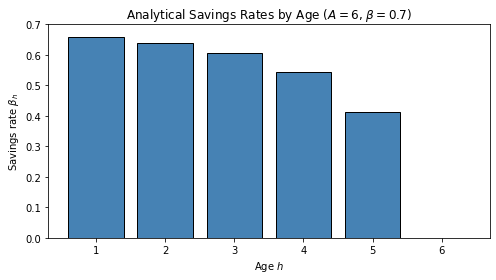


Young agents save the most because they have the longest remaining
horizon. The oldest agent saves nothing — they die next period.


In [3]:
A = 6
beta = 0.7

# Compute savings rates for each cohort h = 1, ..., A-1
savings_rates = []
for h in range(1, A):
    beta_h = beta * (1 - beta**(A - h)) / (1 - beta**(A - h + 1))
    savings_rates.append(beta_h)

# Agent A consumes everything (dies next period)
savings_rates.append(0.0)

# Print savings rates
for h, sr in enumerate(savings_rates, 1):
    print(f"  Agent h={h}: savings rate = {sr:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
ages = np.arange(1, A + 1)
bars = ax.bar(ages, savings_rates, color='steelblue', edgecolor='black')
ax.set_xlabel('Age $h$')
ax.set_ylabel('Savings rate $\\beta_h$')
ax.set_title('Analytical Savings Rates by Age ($A=6$, $\\beta=0.7$)')
ax.set_xticks(ages)
ax.set_ylim(0, 0.7)
plt.tight_layout()
plt.show()

print("\nYoung agents save the most because they have the longest remaining")
print("horizon. The oldest agent saves nothing — they die next period.")

## Task 2: Lifecycle Consumption Profile (10 min)

Given the savings rates from Task 1, simulate the **lifecycle of a single cohort** as it ages from $h=1$ to $h=A$.

Assume steady-state prices:
- Wage: $w = 1.0$ (income of the youngest agent)
- Interest rate: $r = 0.15$

The lifecycle works as follows:
- Agent $h=1$ earns wage $w$, saves $k_2 = \beta_1 \cdot w$, consumes $c_1 = (1-\beta_1) \cdot w$
- Agent $h=2$ earns $r \cdot k_2$, saves $k_3 = \beta_2 \cdot (r \cdot k_2)$, consumes $c_2 = (1-\beta_2) \cdot (r \cdot k_2)$
- ... and so on until agent $A$ consumes everything

In [4]:
# Assume steady-state prices
r = 0.15
w = 1.0

# TODO: Simulate one lifecycle
# Agent 1 earns wage w, saves k2 = beta_1 * w
# Agent 2 earns r*k2, saves k3 = beta_2 * (r*k2)
# ... and so on until agent A consumes everything

# income = [w]
# capital = []
# consumption = []
# for h in range(A):
#     c_h = (1 - savings_rates[h]) * income[h]
#     consumption.append(c_h)
#     if h < A - 1:
#         k_next = savings_rates[h] * income[h]
#         capital.append(k_next)
#         income.append(r * k_next)

# TODO: Plot consumption vs age and capital vs age (2 subplots)

### Solution

Lifecycle simulation (r=0.15, w=1.0):
  Age 1: income = 1.0000, c = 0.3400, k_2 = 0.6600
  Age 2: income = 0.0990, c = 0.0357, k_3 = 0.0633
  Age 3: income = 0.0095, c = 0.0037, k_4 = 0.0057
  Age 4: income = 0.0009, c = 0.0004, k_5 = 0.0005
  Age 5: income = 0.0001, c = 0.0000, k_6 = 0.0000
  Age 6: income = 0.0000, c = 0.0000 (dies)


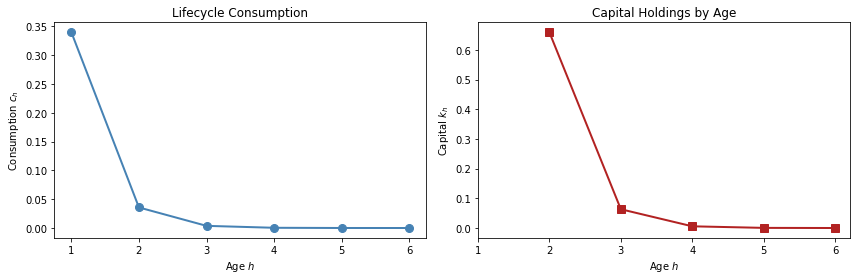


Consumption falls over the lifecycle because capital income (r*k)
shrinks rapidly — each generation saves a smaller fraction of a
smaller income. With r < 1, capital decumulates quickly.


In [5]:
r = 0.15
w = 1.0

# Simulate the lifecycle
income = [w]
capital = []
consumption = []

for h in range(A):
    c_h = (1 - savings_rates[h]) * income[h]
    consumption.append(c_h)
    if h < A - 1:
        k_next = savings_rates[h] * income[h]
        capital.append(k_next)
        income.append(r * k_next)

# Print lifecycle
print("Lifecycle simulation (r={}, w={}):".format(r, w))
for h in range(A):
    cap_str = f", k_{h+2} = {capital[h]:.4f}" if h < A - 1 else " (dies)"
    print(f"  Age {h+1}: income = {income[h]:.4f}, c = {consumption[h]:.4f}{cap_str}")

# 2-panel plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ages = np.arange(1, A + 1)

# Left panel: consumption lifecycle
ax1.plot(ages, consumption, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_xlabel('Age $h$')
ax1.set_ylabel('Consumption $c_h$')
ax1.set_title('Lifecycle Consumption')
ax1.set_xticks(ages)

# Right panel: capital holdings
# Capital k_h is held at the start of age h (for h=2,...,A)
ax2.plot(ages[1:], capital, 's-', color='firebrick', linewidth=2, markersize=8)
ax2.set_xlabel('Age $h$')
ax2.set_ylabel('Capital $k_h$')
ax2.set_title('Capital Holdings by Age')
ax2.set_xticks(ages)

plt.tight_layout()
plt.show()

print("\nConsumption falls over the lifecycle because capital income (r*k)")
print("shrinks rapidly — each generation saves a smaller fraction of a")
print("smaller income. With r < 1, capital decumulates quickly.")

## Task 3: Effect of Patience (10 min)

How does the discount factor $\beta$ affect lifecycle behavior?

Compare lifecycle **consumption profiles** for $\beta \in \{0.5, 0.7, 0.9\}$, keeping $A=6$, $r=0.15$, $w=1.0$ fixed.

Plot all three consumption profiles on the same axes. What happens as $\beta$ increases?

In [6]:
# TODO: Loop over beta_values = [0.5, 0.7, 0.9]
# For each, compute the full lifecycle (savings rates, capital, consumption)
# Plot all 3 consumption profiles on the same axes
# What happens as beta increases?

# beta_values = [0.5, 0.7, 0.9]
# A = 6
# r = 0.15
# w = 1.0
#
# for beta_val in beta_values:
#     # Step 1: compute savings rates
#     sr = []
#     for h in range(1, A):
#         ...
#     sr.append(0.0)
#
#     # Step 2: simulate lifecycle
#     inc = [w]
#     cons = []
#     for h in range(A):
#         ...
#
#     # Step 3: plot
#     plt.plot(range(1, A+1), cons, 'o-', label=f'beta={beta_val}')

### Solution

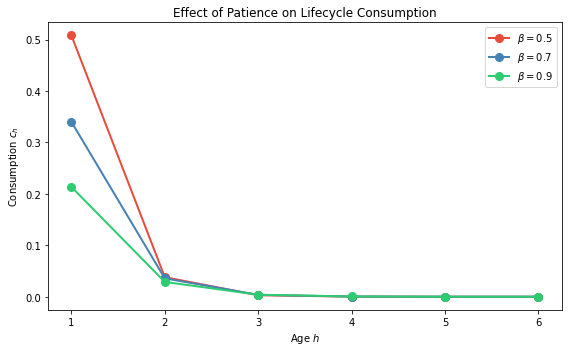

Key insight: More patient agents (higher beta) consume less when
young and save more, building up capital. However, since r < 1,
the capital income still declines — but more patient agents have
a flatter consumption profile (closer to consumption smoothing).


In [7]:
beta_values = [0.5, 0.7, 0.9]
A = 6
r = 0.15
w = 1.0
colors = ['#e74c3c', 'steelblue', '#2ecc71']

fig, ax = plt.subplots(figsize=(8, 5))

for beta_val, color in zip(beta_values, colors):
    # Step 1: compute savings rates
    sr = []
    for h in range(1, A):
        beta_h = beta_val * (1 - beta_val**(A - h)) / (1 - beta_val**(A - h + 1))
        sr.append(beta_h)
    sr.append(0.0)  # oldest agent

    # Step 2: simulate lifecycle
    inc = [w]
    cons = []
    for h in range(A):
        c_h = (1 - sr[h]) * inc[h]
        cons.append(c_h)
        if h < A - 1:
            k_next = sr[h] * inc[h]
            inc.append(r * k_next)

    # Step 3: plot
    ax.plot(range(1, A + 1), cons, 'o-', color=color, linewidth=2,
            markersize=8, label=f'$\\beta = {beta_val}$')

ax.set_xlabel('Age $h$')
ax.set_ylabel('Consumption $c_h$')
ax.set_title('Effect of Patience on Lifecycle Consumption')
ax.set_xticks(range(1, A + 1))
ax.legend()
plt.tight_layout()
plt.show()

print("Key insight: More patient agents (higher beta) consume less when")
print("young and save more, building up capital. However, since r < 1,")
print("the capital income still declines — but more patient agents have")
print("a flatter consumption profile (closer to consumption smoothing).")

## Summary

**Key takeaways from this exercise:**

1. **Savings rates decline with age**: Young agents save a large fraction of income because they have many periods left to enjoy returns. The oldest agent saves nothing.

2. **Lifecycle consumption** depends on both savings behavior and capital returns. With $r < 1$, capital income shrinks rapidly across generations, producing a declining consumption profile.

3. **The discount factor $\beta$ governs the patience-savings tradeoff**: Higher $\beta$ means agents value future consumption more, so they save more when young. This produces a flatter lifecycle profile.

4. **Connection to DEQN**: In Notebook `lecture_09_08_OLG_Analytic_DEQN_persistent.ipynb`, we trained a neural network to learn these savings rates from the Euler equations. The analytical formulas above are the *exact* solution that the network approximates. Comparing DEQN output to these closed-form values is a key validation step.